In [1]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf
import matplotlib.pyplot as plt

X_train = []
Y_train = []
image_size = 150
labels = ['Bacterial Pneumonia','Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']

for label in labels:
    folderPath = os.path.join('dataset/train', label)
    for filename in os.listdir(folderPath):
        print(filename)
        img = cv2.imread(os.path.join(folderPath, filename))
        img = cv2.resize(img, (image_size, image_size))
        X_train.append(img)
        Y_train.append(label)

for label in labels:
    folderPath = os.path.join('dataset/test', label)
    for filename in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath, filename))
        img = cv2.resize(img, (image_size, image_size))
        X_train.append(img)
        Y_train.append(label)
        
for label in labels:
    folderPath = os.path.join('dataset/val', label)
    for filename in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath, filename))
        img = cv2.resize(img, (image_size, image_size))
        X_train.append(img)
        Y_train.append(label)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

X_train, Y_train = shuffle(X_train, Y_train, random_state=100)

x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, test_size=0.2, random_state=100)

y_train = tf.keras.utils.to_categorical([labels.index(label) for label in y_train], num_classes=len(labels))
y_test = tf.keras.utils.to_categorical([labels.index(label) for label in y_test], num_classes=len(labels))

1.jpeg
10.jpeg
117.jpeg
118.jpeg
12.jpeg
120.jpeg
121.jpeg
122.jpeg
123.jpeg
125.jpeg
126.jpeg
127.jpeg
128.jpeg
13.jpeg
130.jpeg
132.jpeg
134.jpeg
139.jpeg
141.jpeg
142.jpeg
145.jpeg
149.jpeg
15.jpeg
150.jpeg
151.jpeg
158.jpeg
159.jpeg
160.jpeg
161.jpeg
162.jpeg
163.jpeg
170.jpeg
171.jpeg
175.jpeg
176.jpeg
177.jpeg
178.jpeg
180.jpeg
182.jpeg
184.jpeg
187.jpeg
19.jpeg
191.jpeg
196.jpeg
198.jpeg
204.jpeg
206.jpeg
208.jpeg
209.jpeg
218.jpeg
228.jpeg
229.jpeg
231.jpeg
233.jpeg
234.jpeg
239.jpeg
240.jpeg
241.jpeg
242.jpeg
247.jpeg
249.jpeg
251.jpeg
254.jpeg
255.jpeg
264.jpeg
265.jpeg
266.jpeg
276.jpeg
277.jpeg
278.jpeg
279.jpeg
282.jpeg
283.jpeg
288.jpeg
289.jpeg
294.jpeg
295.jpeg
299.jpeg
300.jpeg
303.jpeg
304.jpeg
305.jpeg
307.jpeg
308.jpeg
310.jpeg
311.jpeg
313.jpeg
319.jpeg
320.jpeg
323.jpeg
324.jpeg
326.jpeg
327.jpeg
33.jpeg
338.jpeg
34.jpeg
341.jpeg
342.jpeg
343.jpeg
344.jpeg
345.jpeg
35.jpeg
355.jpeg
358.jpeg
359.jpeg
36.jpeg
361.jpeg
364.jpeg
366.jpeg
367.jpeg
368.jpeg
369.jpeg
370

In [2]:
print('Training data shape: ', x_train.shape)
print('Training labels shape: ', y_train.shape)
print('Testing data shape: ', x_test.shape)
print('Testing labels shape: ', y_test.shape)
print('Number of classes: ', len(labels))

Training data shape:  (8076, 150, 150, 3)
Training labels shape:  (8076, 5)
Testing data shape:  (2019, 150, 150, 3)
Testing labels shape:  (2019, 5)
Number of classes:  5


In [3]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))

# Freeze the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(256, activation='relu')(x)
output = Dense(5, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [4]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 156, 156,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 75, 75,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 75, 75,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 75, 75,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 77, 77,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 38, 38,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 38, 38,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 38, 38,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 38, 38,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 38, 38,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 38, 38,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 38, 38,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 38, 38,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 38, 38,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 38, 38,    │      1,024 │ conv2_block1_3_c

 Total params: 24,179,333 (92.24 MB)

 Trainable params: 591,621 (2.26 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

try:
    model.optimizer
except AttributeError:
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train, epochs=50, validation_split=0.1,
    callbacks=[early_stopping]
)

model.save('model/lung_disease_detection_model.h5')

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred_classes)
f1 = f1_score(y_true, y_pred_classes, average='weighted')
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 193s 797ms/step - accuracy: 0.7253 - loss: 0.7020 - val_accuracy: 0.8540 - val_loss: 0.3584
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.8575 - loss: 0.3518 - val_accuracy: 0.8490 - val_loss: 0.3320
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8726 - loss: 0.3033 - val_accuracy: 0.8465 - val_loss: 0.3432
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.8845 - loss: 0.2701 - val_accuracy: 0.8651 - val_loss: 0.3150
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.8992 - loss: 0.2489 - val_accuracy: 0.8564 - val_loss: 0.3163
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.9026 - loss: 0.2277 - val_accuracy: 0.8725 - val_loss: 0.3250
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.9006 - loss: 0.2451 - val_accuracy: 0.8465 - val_loss: 0.3940
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.9190 - loss: 0.1921 - val_a

64/64 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step
Accuracy: 0.861812778603269
F1 Score: 0.859187960082178
Precision: 0.870182917092225
Recall: 0.861812778603269


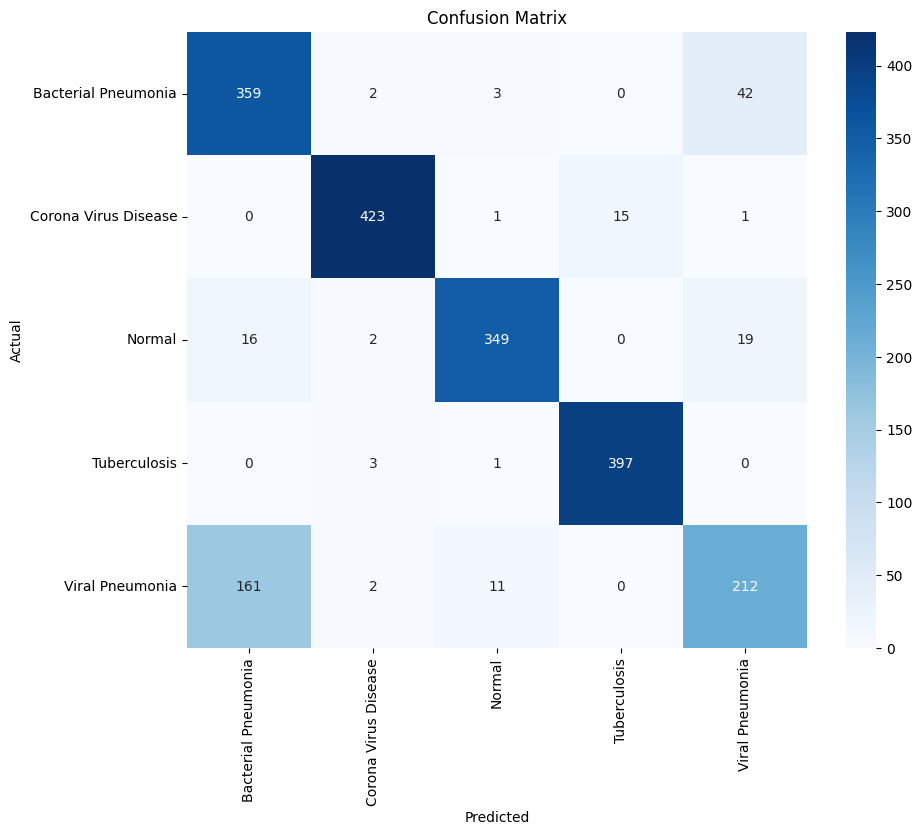

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
class_names = ['Bacterial Pneumonia','Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

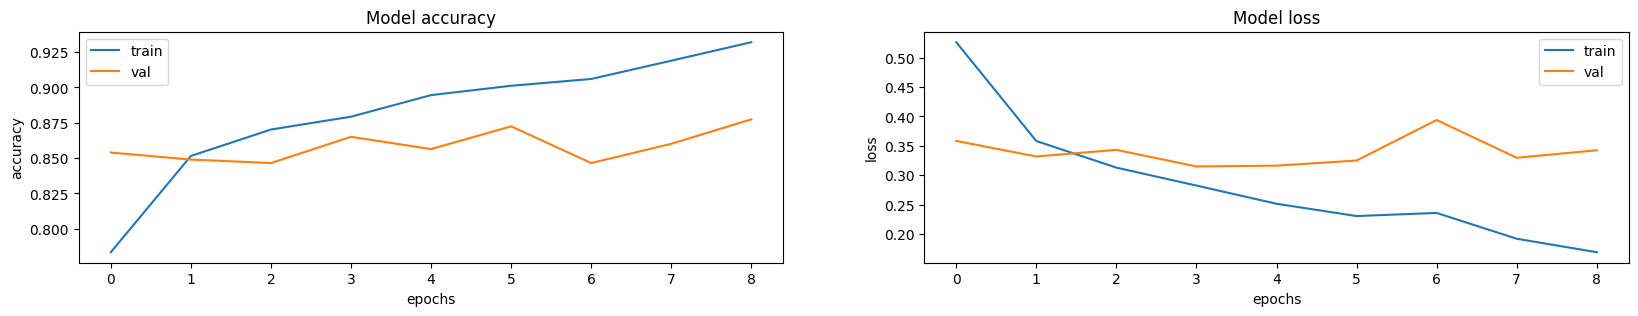

In [7]:
accuracy = history.history['accuracy']
val_accuracy  = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 3))
ax = ax.ravel()

for i, met in enumerate(['accuracy', 'loss']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].legend(['train', 'val'])

plt.show()